# Mohajer m vs NDCG@10 on TREC-COVID

Sweep the Mohajer ranker's `m` parameter and measure how it affects NDCG@10 on the TREC-COVID reranking matrix. All runs reuse the same seed and cached data so only the sampling budget controlled by `m` is changing.


In [1]:
from typing import Sequence

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from ireranker.data.loaders import load_beir_dataset
from ireranker.evaluation.beir import evaluate_rankers_beir
from ireranker.rankers import get_ranker

plt.style.use('ggplot')


2025-11-25 18:42:57.069 | INFO     | ireranker.config:<module>:14 - PROJ_ROOT path is: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker


In [2]:
from pathlib import Path
import json

CONFIG_PATH = Path('../config/beir_eval.json').resolve()
cfg = json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}
ALL_DATASETS = [d.lower() for d in cfg.get('datasets', [])]
LIGHT_EXCLUDE = {d.lower() for d in cfg.get('light_exclude', [])}
LIGHT_DATASETS = [d for d in ALL_DATASETS if d not in LIGHT_EXCLUDE]

SEEDS = [42]
K_VALUES = [10]
M_VALUES = np.linspace(0, 2, 50)

print('Datasets (light mode):', ', '.join(LIGHT_DATASETS))
print(f'Running {len(SEEDS)} seeds: {SEEDS}')


Datasets (light mode): webis-touche2020, nfcorpus, trec-covid, scifact
Running 1 seeds: [42]


In [3]:
def evaluate_m_values(dataset_name: str, m_values: Sequence[float], seeds: Sequence[int]) -> pd.DataFrame:
    dataset = load_beir_dataset(dataset_name, split='test')
    rows = []
    for seed in seeds:
        for m in m_values:
            ranker = get_ranker('mohajer', seed=seed)
            ranker.m = m
            ranker.set_dataset(dataset_name, split='test')
            result = evaluate_rankers_beir([ranker], dataset, K_VALUES, seed=seed)[0]
            rows.append({
                'dataset': dataset_name,
                'seed': seed,
                'm': m,
                'NDCG@10': float(result['NDCG']),
                'MAP@10': float(result['MAP']),
                'Recall@10': float(result['Recall']),
                'P@10': float(result['Precision']),
                'Comparisons': int(result['Comparisons']),
                'NDCG_per_comp': float(result['NDCG_per_comp']),
            })
    return pd.DataFrame(rows).sort_values(['dataset', 'seed', 'm']).reset_index(drop=True)

m_sweep_df = pd.concat(
    [evaluate_m_values(ds, M_VALUES, SEEDS) for ds in LIGHT_DATASETS],
    ignore_index=True,
)
m_sweep_df


/home/jerefigo/.local/lib/python3.10/site-packages/beir/util.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


2025-11-25 18:42:58.770 | INFO     | ireranker.data.loaders:_download_beir_once:79 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/webis-touche2020
2025-11-25 18:43:01.009 | INFO     | ireranker.data.loaders:_load_rerank_matrix:151 - Loaded rerank matrix for webis-touche2020/test (queries: 49)
2025-11-25 18:43:01.010 | INFO     | ireranker.data.loaders:load_beir_dataset:229 - Using rerank matrix for 49 queries in webis-touche2020/test


Evaluating rankers: 100%|██████████| 1/1 [00:00<00:00,  6.01it/s]


2025-11-25 18:43:05.980 | INFO     | ireranker.data.loaders:_download_beir_once:79 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/nfcorpus
2025-11-25 18:43:15.492 | INFO     | ireranker.data.loaders:_load_rerank_matrix:151 - Loaded rerank matrix for nfcorpus/test (queries: 295)
2025-11-25 18:43:15.495 | INFO     | ireranker.data.loaders:load_beir_dataset:229 - Using rerank matrix for 295 queries in nfcorpus/test


Evaluating rankers: 100%|██████████| 1/1 [00:00<00:00,  1.34it/s]


2025-11-25 18:43:37.983 | INFO     | ireranker.data.loaders:_download_beir_once:79 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/trec-covid
2025-11-25 18:43:40.884 | INFO     | ireranker.data.loaders:_load_rerank_matrix:151 - Loaded rerank matrix for trec-covid/test (queries: 50)
2025-11-25 18:43:40.884 | INFO     | ireranker.data.loaders:load_beir_dataset:229 - Using rerank matrix for 50 queries in trec-covid/test


Evaluating rankers: 100%|██████████| 1/1 [00:00<00:00,  5.86it/s]


2025-11-25 18:43:46.002 | INFO     | ireranker.data.loaders:_download_beir_once:79 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/scifact
2025-11-25 18:44:01.539 | INFO     | ireranker.data.loaders:_load_rerank_matrix:151 - Loaded rerank matrix for scifact/test (queries: 300)
2025-11-25 18:44:01.544 | INFO     | ireranker.data.loaders:load_beir_dataset:229 - Using rerank matrix for 300 queries in scifact/test


Evaluating rankers: 100%|██████████| 1/1 [00:01<00:00,  1.01s/it]


,dataset,seed,m,NDCG@10,MAP@10,Recall@10,P@10,Comparisons,NDCG_per_comp
0,webis-touche2020,42,0.000000,0.13144,0.05390,0.12312,0.11633,0,0.000000
1,webis-touche2020,42,0.040816,0.14218,0.05700,0.12789,0.12449,428,0.000332
2,webis-touche2020,42,0.081633,0.13192,0.05316,0.12956,0.12449,904,0.000146
3,webis-touche2020,42,0.122449,0.12334,0.04893,0.11666,0.11020,1458,0.000085
4,webis-touche2020,42,0.163265,0.14737,0.06357,0.12064,0.12245,1990,0.000074
...,...,...,...,...,...,...,...,...,...
195,scifact,42,1.836735,0.68160,0.62898,0.83572,0.09462,131044,0.000005
196,scifact,42,1.877551,0.66510,0.61163,0.81840,0.09211,134040,0.000005
197,scifact,42,1.918367,0.66691,0.61764,0.80317,0.09104,137152,0.000005
198,scifact,42,1.959184,0.67800,0.62884,0.81302,0.09176,140310,0.000005


In [4]:
best_overall = m_sweep_df.loc[m_sweep_df['NDCG@10'].idxmax()]
mean_by_ds = m_sweep_df.groupby(['dataset', 'm'])['NDCG@10'].mean().reset_index()
best_by_dataset = mean_by_ds.loc[mean_by_ds.groupby('dataset')['NDCG@10'].idxmax()]
best_overall, best_by_dataset[['dataset', 'm', 'NDCG@10']]


(dataset          trec-covid
 seed                     42
 m                  1.836735
 NDCG@10             0.79438
 MAP@10              0.20366
 Recall@10           0.22682
 P@10                   0.83
 Comparisons           21852
 NDCG_per_comp      0.000036
 Name: 145, dtype: object,
               dataset         m  NDCG@10
 36           nfcorpus  1.469388  0.60340
 81            scifact  1.265306  0.69029
 145        trec-covid  1.836735  0.79438
 187  webis-touche2020  1.510204  0.30403)

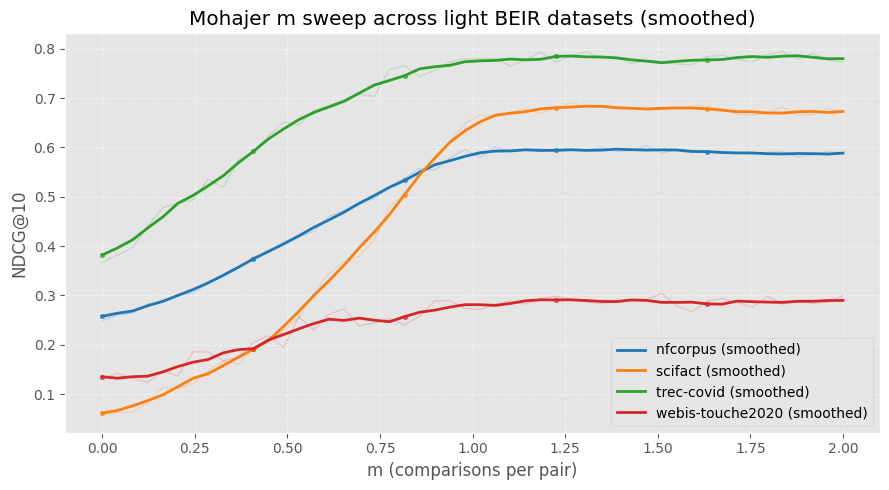

In [5]:
mean_by_ds = (
    m_sweep_df.groupby(['dataset', 'm'])['NDCG@10'].agg(['mean', 'std']).reset_index()
    .sort_values(['dataset', 'm'])
)

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(9, 5))
for idx, (ds, sub) in enumerate(mean_by_ds.groupby('dataset')):
    color = colors[idx % len(colors)]
    smoothed = sub['mean'].rolling(window=5, center=True, min_periods=1).mean()
    ax.plot(sub['m'], smoothed, linewidth=2, color=color, label=f"{ds} (smoothed)")
    ax.plot(sub['m'], sub['mean'], color=color, alpha=0.18, linewidth=1)
    ax.scatter(sub['m'][::10], smoothed.iloc[::10], color=color, s=10, alpha=0.7)
    if sub['std'].notna().any():
        lower = smoothed - sub['std']
        upper = smoothed + sub['std']
        ax.fill_between(sub['m'], lower, upper, color=color, alpha=0.06)

ax.set_xlabel('m (comparisons per pair)')
ax.set_ylabel('NDCG@10')
ax.set_title('Mohajer m sweep across light BEIR datasets (smoothed)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


- Reuse the cached rerank matrix under `data/external/reranking-matrices` and the BEIR dataset cache under `data/external/beir`.
- Adjust `M_VALUES` to try different sampling budgets or add finer granularity.
- Keep the seed fixed when you want to compare only the effect of `m`; change it to check robustness across random draws.
